# Stanford CME 241 (Winter 2026) - Assignment 1

**Due: Friday, January 23 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):*

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):*
- Person 1
- Person 2
- Person 3

## Imports

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
from collections import defaultdict
from rl.markov_process import FiniteMarkovProcess, NonTerminal, Terminal
from rl.distribution import Categorical
import matplotlib.pyplot as plt

## Question 1: Snakes and Ladders (Led by Lucas Tellez)

In the classic childhood game of Snakes and Ladders, all players start to the left of square 1 (call this position 0) and roll a 6-sided die to represent the number of squares they can move forward. The goal is to reach square 100 as quickly as possible. Landing on the bottom rung of a ladder allows for an automatic free-pass to climb, e.g. square 4 sends you directly to 14; whereas landing on a snake's head forces one to slide all the way to the tail, e.g. square 34 sends you to 6. Note, this game can be viewed as a Markov Process, where the outcome is only depedent on the current state and not the prior trajectory. In this question, we will ask you to both formally describe the Markov Process that describes this game, followed by coding up a version of the game to get familiar with the RL-book libraries.


### Problem Statement

How can we model this problem with a Markov Process?

---

### Subquestions

#### Part (A): MDP Modeling

Formalize the state space of the Snakes and Ladders game. Don't forget to specify the terminal state!

---

#### Part (B): Transition Probabilities

Write out the structure of the transition probabilities. Feel free to abbreviate all squares that do not have a snake or ladder.

---

#### Part (C): Modeling the Game

Code up a `transition_map: Transition[S]` data structure to represent the transition probabilities of the Snakes and Ladders Markov Process so you can model the game as an instance of `FiniteMarkovProcess`. Use the `traces` method to create sampling traces, and plot the graph of the distribution of time steps to finish the game. Use the image provided for the locations of the snakes and ladders.

https://drive.google.com/file/d/1yhP242sG092Ico_WOPKrUp8jVJHbuGHH/view?usp=sharing

---

### Part (A) Answer

Let $n$ be the number of players in the game. Then the state space $\mathcal{S}$ is described by any n-tuple in $\{0,...,100\}^n$ (i.e with integer entries from 0 to 100), with the set of terminal states $\mathcal{T}$ described by the states with any entry equal to 100. The reward function $R$ is a deterministic function of the state, with 1 reward given for winning the game (i.e reaching a terminal state where your integer is 100) and 0 reward otherwise. The action distribution cannot be changed by the player, and is entirely determined by the state (where the player is and if the game is not over) and by the presumably uniform distribution of the die rolls.

### Part (B) Answer

Let $f:\mathbb Z_{\geq 0} \rightarrow \{0,...,100\}$ be given as follows. For any $k \in \{0,...,100\}$ with no ladder bottom or snakehead, $f$ is the identity (i.e $f(k) = k$). When $k$ is at a ladder bottom, then $f(k)$ gives the ladder top, while if $k$ is at a snake head $f(k)$ is at the tail of the snake. Finally if $k > 100$ then $f(k) := f(100 - (k \mod 100))$. We can now compactly represent the transition probability for player $j$'s turn from position $k$ in a nonterminal state $S$ as $$ p_j(k,k') = |f^{-1}(k')\cap\{k+1,k+2,...,k+6\}|/6 $$ 

### Part (C) Answer

[49, 13, 31, 17, 46, 81, 25, 43, 18, 21, 84, 20, 9, 24, 19, 33, 17, 28, 21, 26, 32, 15, 107, 14, 67, 36, 55, 67, 65, 29, 8, 34, 122, 54, 36, 24, 17, 29, 59, 68, 21, 32, 29, 25, 16, 36, 33, 67, 41, 45, 90, 13, 52, 45, 18, 41, 62, 37, 27, 122, 27, 32, 52, 29, 26, 19, 72, 26, 35, 23, 42, 19, 24, 24, 68, 20, 27, 28, 35, 35, 17, 23, 40, 26, 12, 22, 34, 36, 11, 47, 70, 35, 73, 17, 36, 26, 37, 47, 24, 33, 32, 43, 26, 34, 17, 29, 47, 119, 42, 14, 11, 53, 52, 50, 36, 38, 13, 64, 18, 37, 21, 43, 80, 15, 19, 40, 29, 26, 23, 52, 54, 14, 75, 80, 49, 19, 28, 91, 28, 68, 81, 26, 39, 28, 20, 48, 79, 37, 70, 37, 34, 25, 26, 35, 35, 93, 36, 17, 50, 27, 51, 26, 23, 42, 20, 52, 38, 24, 41, 49, 104, 17, 32, 29, 82, 36, 34, 12, 26, 55, 57, 27, 20, 11, 19, 15, 21, 35, 110, 53, 48, 53, 11, 49, 35, 45, 102, 30, 34, 120, 15, 62, 27, 63, 26, 17, 12, 45, 26, 73, 31, 69, 54, 111, 43, 37, 65, 16, 35, 12, 12, 28, 25, 51, 26, 38, 119, 101, 17, 20, 46, 69, 36, 94, 14, 16, 235, 24, 128, 56, 22, 88, 17, 31, 29, 58, 18, 

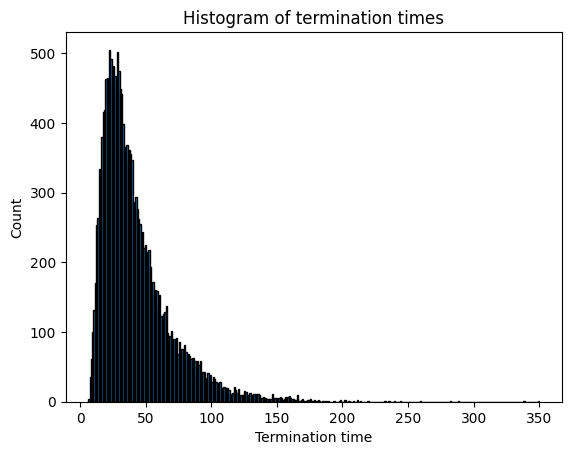

In [ ]:
# Assuming one player since no number of players is specified.
f = {1 : 38 , 4 : 14 , 8 : 30 , 21 : 42 , 28 : 76 , 32 : 10 , 36 : 6 , 48 : 26 , 50 : 67 , 62 : 18 , 71 : 92 , 80 : 99 , 88 : 24 , 95 : 56 , 97 : 78 , 101 : 99 , 102 : 98 , 103 : 97 , 104 : 96 , 105 : 95}
for i in range(1,101):
    if i not in f.keys():
        f[i] = i

P = {}

for k in range(0, 100 + 1):
    counts = defaultdict(int)

    for x in range(k + 1, k + 7):
        y = f.get(x)
        if y is None:
            continue
        if 1 <= y <= 100:
            counts[y] += 1

    P[k] = {kp: c / 6 for kp, c in counts.items()}

transition_map = {
    s: Categorical(P[s])
    for s in range(100)
    }
sl = FiniteMarkovProcess(transition_map)
start_dist = Categorical({NonTerminal(0): 1.0})
def termination_time(mp, start_dist) -> int:
    t = 0
    for st in mp.simulate(start_dist):
        if not isinstance(st, NonTerminal):
            return t
        t += 1

N = 20_000
times = [termination_time(sl, start_dist) for _ in range(N)]
plt.hist(times, bins=range(min(times), max(times)+2), edgecolor="black")
plt.xlabel("Termination time")
plt.ylabel("Count")
plt.title("Histogram of termination times")
plt.show()

## Question 2: Markov Decision Processes (Led by Lucas Tellez)

Consider an MDP with an infinite set of states ${S} = \{1,2,3,\ldots \}$. The start state is $s=1$. Each state $s$ allows a continuous set of actions $a \in [0,1]$. The transition probabilities are given by:
$$\mathbb{P}[s+1 \mid s, a] = a, \mathbb{P}[s \mid s, a] = 1 - a \text{ for all } s \in S \text{ for all } a \in [0,1]$$
For all states $s \in {S}$ and actions $a \in [0,1]$, transitioning from $s$ to $s+1$ results in a reward of $1-a$ and transitioning from $s$ to $s$ results in a reward of $1+a$. The discount factor $\gamma=0.5$.

### Problem Statement

How can we derive a mathematical formulation for the value function and the optimal policy? And how do those functions change when we modify the action space?

---

### Subquestions

#### Part (A): Optimal Value Function  

Using the MDP Bellman Optimality Equation, calculate the Optimal Value Function $V^*(s)$ for all $s \in {S}$. Given $V^*(s)$, what is the optimal action, $a^*$, that maximizes the optimal value function?

---

#### Part (B): Optimal Policy  

Calculate an Optimal Deterministic Policy $\pi^*(s)$ for all $s \in {S}$.

---

#### Part (C): Changing the Action Space  

Let's assume that we modify the action space such that instead of $a \in [0,1]$ for all states, we restrict the action space to $a \in \left[0,\frac{1}{s}\right]$ for state $s$. This means that higher states have more restricted action spaces. How does this constraint affect:

- The form of the Bellman optimality equation?
- The optimal value function, $V^*(s)$?
- The structure of the optimal policy, $\pi^*(s)$?

---

### Part (A) Answer

Plugging in the problem dynamics to the Bellman Optimality equation yields
$$
V^*(s)=\max_{a\in[0,1]}\Big[ a\big((1-a)+\gamma V^*(s+1)\big) + (1-a)\big((1+a)+\gamma V^*(s)\big)\Big].
$$
The transition probabilities and rewards are identical for every state label $s$, so the optimal value is translation-invariant, i.e. $V^*(s)$ is constant over $s$. Let $V^*(s)=V^*$ for all $s$. Then $V^*(s+1)=V^*$ as well, and the Bellman equation reduces to
$$
V^*=\max_{a\in[0,1]}\Big[ a(1-a)+(1-a)(1+a)+\gamma V^*\Big]
=\max_{a\in[0,1]}\Big[1+a-2a^2+\tfrac12 V^*\Big].
$$
Rearranging gives
$$
V^* = 2\max_{a\in[0,1]}\big[1+a-2a^2\big].
$$
To find this maximum, differentiate the expression to be maximized:
$$
\frac{d}{da}(1+a-2a^2)=1-4a=0 \implies a^*=\frac14.
$$
Plugging back in,
$$
\max_{a\in[0,1]}(1+a-2a^2)=1+\frac14-2\cdot\frac{1}{16}=\frac98
\implies
V^*=2\cdot\frac98=\frac94.
$$


### Part (B) Answer

As outlined in part a, the optimal deterministic policy is to always take action $a = \frac{1}{4}$ at every state.

### Part (C) Answer

#### Bellman Optimality Equation:

The Bellman optimality equation is the maximization over the state-dependent action set.
$$
V^*(s)=\max_{a\in[0,1/s]}\Big[a(1-a)+(1-a)(1+a)+\gamma\big((1-a)V^*(s)+aV^*(s+1)\big)\Big].
$$
Using $\gamma=\tfrac12$ and simplifying the immediate expected reward term $a(1-a)+(1-a)(1+a)=1+a-2a^2$, this can be written as
$$
V^*(s)=\max_{a\in[0,1/s]}\Big[1+a-2a^2+\tfrac12\big((1-a)V^*(s)+aV^*(s+1)\big)\Big].
$$
In effect, the set of actions to maximize over becomes dependent on the state.

#### Optimal Value Function Change:

The optimal value function is no longer constant because the feasible action set $[0,1/s]$ depends on $s$ (even though the reward formula itself does not explicitly depend on $s$). As $s$ increases, the allowed actions shrink toward $0$, so the optimal expected per-step reward approaches $1$ and $V^*(s)$ approaches a finite limit (intuitively on the order of $1/(1-\gamma)=2$).

#### Optimal Policy Change:

The optimal deterministic policy is generally state-dependent. For each state $s$, the optimal action $\pi^*(s)$ is the maximizer of the Bellman objective over $a\in[0,1/s]$, i.e.,
$$
\pi^*(s)\in\arg\max_{a\in[0,1/s]}\Big[1+a-2a^2+\tfrac12\big((1-a)V^*(s)+aV^*(s+1)\big)\Big].
$$
It must satisfy $0\le \pi^*(s)\le 1/s$, hence $\lim_{s\to\infty}\pi^*(s)=0$.


## Question 3: Frog in a Pond (Led by Sam Layton)

Consider an array of $n+1$ lilypads on a pond, numbered $0$ to $n$. A frog sits on a lilypad other than the lilypads numbered $0$ or $n$. When on lilypad $i$ ($1 \leq i \leq n-1$), the frog can croak one of two sounds: **A** or **B**.

- If it croaks **A** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to lilypad $i-1$ with probability $\frac{i}{n}$.
  - It is thrown to lilypad $i+1$ with probability $\frac{n-i}{n}$.
  
- If it croaks **B** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to one of the lilypads $0, \ldots, i-1, i+1, \ldots, n$ with uniform probability $\frac{1}{n}$.

A snake, perched on lilypad $0$, will eat the frog if it lands on lilypad $0$. The frog can escape the pond (and hence, escape the snake!) if it lands on lilypad $n$.

### Problem Statement

What should the frog croak when on each of the lilypads $1, 2, \ldots, n-1$, in order to maximize the probability of escaping the pond (i.e., reaching lilypad $n$ before reaching lilypad $0$)?

Although there are multiple ways to solve this problem, we aim to solve it by modeling it as a **Markov Decision Process (MDP)** and identifying the **Optimal Policy**.

---

### Subquestions

#### Part (A): MDP Modeling

Express the frog-escape problem as an MDP using clear mathematical notation by defining the following components:

- **State Space**: Define the possible states of the MDP.
- **Action Space**: Specify the actions available to the frog at each state.
- **Transition Function**: Describe the probabilities of transitioning between states for each action.
- **Reward Function**: Specify the reward associated with the states and transitions.

---

#### Part (B): Python Implementation

There is starter code below to solve this problem programatically. Fill in each of the $6$ `TODO` areas in the code. As a reference for the transition probabilities and rewards, you can make use of the example in slide 16/31 from the following slide deck: https://github.com/coverdrive/technical-documents/blob/master/finance/cme241/Tour-MP.pdf.

Write Python code that:

- Models this MDP.
- Solves the **Optimal Value Function** and the **Optimal Policy**.

Feel free to use/adapt code from the textbook. Note, there are other libraries that are needed to actually run this code, so running it will not do anything. Just fill in the code so that it could run assuming that the other libraries are present.

---

#### Part (C): Visualization and Analysis

What patterns do you observe for the **Optimal Policy** as you vary $n$ from $3$ to $25$? When the frog is on lilypad $13$ (with $25$ total), what action should the frog take? Is this action different than the action the frog should take if it is on lilypad $1$?

---

### Part (A) Answer

#### State Space:  

The state space is S = {0, ... , n} with terminal states T = {0,n}

#### Action Space:  

The action space is {A,B}

#### Transition Function:  

given $s_t \in S$ and $a \in \{A,B\}$, then defining a helper function $g$

$$
g(i, s_{t-1}) =
\begin{cases}
\frac{s_{t-1}}{n},  & i = s_{t-1} - 1 \\
1-\frac{s_{t-1}}{n},  & i = s_{t-1} + 1 \\
0, & \text{else} \\
\end{cases}
$$

and defining helper function h:

$$
h(i,s_{t-1}) =
\begin{cases}
0, & i = s_{t-1} \\
\frac{1}{n}, & \text{else}
\end{cases}
$$

We can use to get our transition function for non terminal states:

$$
P(s_t = i| s_{t-1}, a) =
\begin{cases}
g(i,s_{t-1}), & a = A \\
h(i,s_{t-1}),  & a = B \\
\end{cases}
$$

And for terminal states, they are certainly persistent. i.e. $P(s_t = 0|s_{t-1}=0,*)=P(s_t = n|s_{t-1}=n,*)=1$


#### Reward Function:  

I define the reward function as follows:
$$
R(s_t) =
\begin{cases}
1,  & s_t = n\\
0, & \text{else}
\end{cases}
$$

### Part (B) Answer

In [2]:
MDPRefined = dict
def get_lily_pads_mdp(n: int) -> MDPRefined:
    data = {
        i: {
            'A': {
                i - 1: i/n,
                i + 1: (n-i)/n,
            },
            'B': {
                j: 1 / n for j in range(0, n + 1) if j != i
            }
        } for i in range(1, n)
    }
    data[0] = {'A': {0: 1}, 'B': {0: 1}}
    data[n] = {'A': {n: 1}, 'B': {n: 1}}

    gamma = 1.0
    return MDPRefined(data, gamma)

Mapping = dict
def direct_bellman(n: int) -> Mapping[int, float]:
    vf = [0.5] * (n + 1)
    vf[0] = 0.
    vf[n] = 0.
    tol = 1e-8
    epsilon = tol * 1e4
    while epsilon >= tol:
        old_vf = [v for v in vf]
        for i in range(1, n):
            # fill in with the Bellman update
            A = (i / n) * vf[i - 1] + ((n - i) / n) * (vf[i + 1] + (1.0 if i + 1 == n else 0.0))
            B = (sum(vf) - vf[i] + 1.0) / n
            vf[i] = max(A,B)
                        
        epsilon = max(abs(old_vf[i] - v) for i, v in enumerate(vf))
    return {v: f for v, f in enumerate(vf)}

# get the value functions for the different n values
n_vals = [3,5,10,15,25]
value_dicts = {n: direct_bellman(n) for n in n_vals}

### Part (C) Answer

From our code below, we see that for $n=3,5,10,15,25$ it all follows the same pattern. Randomize with croak B at lilypad 1, and take your chances with A at every other lilypad. This makes intuitive sense as the probability of being eaten by the snake while at lilypad 1 is the same regardless of A and B, but A has a chance to move you to lilypad 2, while B will move you anywhere, with a higher expected value of moving you away from the snake. Croak A essentially walks around randomly with a drift towards the middle, however there are times when it may approach either end. Croak B resets, while croak A lets it keep drifitng. Think of croak B as a desperate jump (with some chance of death equivalent to croak A) but croak B has a much higher expected value of moving away from the snake.

To answer the question directly, for $n=25$, lilypad 13 optimal choice is A, while lilypad 1 has optimal choice B.

In [4]:
def print_policy(n, vf_map):
    print(f"\n--- Optimal Policy for N={n} ---")
    
    # Ensure we can access values by index, whether input is dict or list
    vf = vf_map if isinstance(vf_map, list) else [vf_map[i] for i in range(n + 1)]
    
    total_value_sum = sum(vf) # Pre-calculate sum of probabilities
    
    for i in range(1, n):
        # Action A Calculation
        val_A = (i/n) * vf[i-1] + ((n-i)/n) * (vf[i+1] + (1.0 if i+1==n else 0.0))
        
        # Action B Calculation (Corrected)
        # Sum of all probabilities - value of current + reward for landing on n
        val_B = (total_value_sum - vf[i] + 1.0) / n
        
        best_action = "A" if val_A > val_B else "B"
        print(f"Lilypad {i}: {best_action}  (A: {val_A:.3f}, B: {val_B:.3f})")


# Print the policy for each n value
for n, val_function in value_dicts.items():
    print_policy(n, val_function)


--- Optimal Policy for N=3 ---
Lilypad 1: B  (A: 0.476, B: 0.571)
Lilypad 2: A  (A: 0.714, B: 0.524)

--- Optimal Policy for N=5 ---
Lilypad 1: B  (A: 0.557, B: 0.643)
Lilypad 2: A  (A: 0.696, B: 0.632)
Lilypad 3: A  (A: 0.732, B: 0.625)
Lilypad 4: A  (A: 0.786, B: 0.614)

--- Optimal Policy for N=10 ---
Lilypad 1: B  (A: 0.633, B: 0.676)
Lilypad 2: A  (A: 0.703, B: 0.673)
Lilypad 3: A  (A: 0.710, B: 0.672)
Lilypad 4: A  (A: 0.713, B: 0.672)
Lilypad 5: A  (A: 0.715, B: 0.672)
Lilypad 6: A  (A: 0.717, B: 0.672)
Lilypad 7: A  (A: 0.720, B: 0.671)
Lilypad 8: A  (A: 0.727, B: 0.671)
Lilypad 9: A  (A: 0.754, B: 0.668)

--- Optimal Policy for N=15 ---
Lilypad 1: B  (A: 0.645, B: 0.671)
Lilypad 2: A  (A: 0.691, B: 0.670)
Lilypad 3: A  (A: 0.694, B: 0.669)
Lilypad 4: A  (A: 0.695, B: 0.669)
Lilypad 5: A  (A: 0.695, B: 0.669)
Lilypad 6: A  (A: 0.695, B: 0.669)
Lilypad 7: A  (A: 0.695, B: 0.669)
Lilypad 8: A  (A: 0.695, B: 0.669)
Lilypad 9: A  (A: 0.695, B: 0.669)
Lilypad 10: A  (A: 0.696, B: 0

## Question 4: Manual Value Iteration (Led by ______)

Consider a simple MDP with ${S} = \{s_1, s_2, s_3\}, {T} = \{s_3\}, {A} = \{a_1, a_2\}$. The State Transition Probability function  
$${P}: {N} \times {A} \times {S} \rightarrow [0, 1]$$  
is defined as:  
$${P}(s_1, a_1, s_1) = 0.25, {P}(s_1, a_1, s_2) = 0.65, {P}(s_1, a_1, s_3) = 0.1$$  
$${P}(s_1, a_2, s_1) = 0.1, {P}(s_1, a_2, s_2) = 0.4, {P}(s_1, a_2, s_3) = 0.5$$  
$${P}(s_2, a_1, s_1) = 0.3, {P}(s_2, a_1, s_2) = 0.15, {P}(s_2, a_1, s_3) = 0.55$$  
$${P}(s_2, a_2, s_1) = 0.25, {P}(s_2, a_2, s_2) = 0.55, {P}(s_2, a_2, s_3) = 0.2$$  

The Reward Function  
$${R}: {N} \times {A} \rightarrow \mathbb{R}$$  
is defined as:  
$${R}(s_1, a_1) = 8.0, {R}(s_1, a_2) = 10.0$$  
$${R}(s_2, a_1) = 1.0, {R}(s_2, a_2) = -1.0$$  

Assume a discount factor of $\gamma = 1$.

### Problem Statement

Your task is to determine an Optimal Deterministic Policy **by manually working out** (not with code) the first two iterations of the Value Iteration algorithm.

---

### Subquestions

#### Part (A): 2 Iterations

1. Initialize the Value Function for each state to be its $\max$ (over actions) reward, i.e., we initialize the Value Function to be $v_0(s_1) = 10.0, v_0(s_2) = 1.0, v_0(s_3) = 0.0$. Then manually calculate $q_k(\cdot, \cdot)$ and $v_k(\cdot)$ from $v_{k - 1}(\cdot)$ using the Value Iteration update, and then calculate the greedy policy $\pi_k(\cdot)$ from $q_k(\cdot, \cdot)$ for $k = 1$ and $k = 2$ (hence, 2 iterations).

---

#### Part (B): Argument

1. Now argue that $\pi_k(\cdot)$ for $k > 2$ will be the same as $\pi_2(\cdot)$. *Hint*: You can make the argument by examining the structure of how you get $q_k(\cdot, \cdot)$ from $v_{k-1}(\cdot)$. With this argument, there is no need to go beyond the two iterations you performed above, and so you can establish $\pi_2(\cdot)$ as an Optimal Deterministic Policy for this MDP.

---

#### Part (C): Policy Evaluation

1. Using the policy $\pi_2(\cdot)$, compute the exact value function $V^{\pi_2}(s)$ for all $s\in S$.

---

#### Part (D): Sensitivity Analysis

Assume the reward for $R(s_1, a_2)$ is modified to $11.0$ instead of $10.0$.

1. Perform one iteration of Value Iteration starting from the initialized value function $v_0(s)$, where $v_0(s)$ remains the same as in the original problem.
2. Determine whether this change impacts the Optimal Deterministic Policy $\pi(\cdot)$. If it does, explain why.

---

### Part (A) Answer

0. Initialization
v0 = [10, 1, 0]
1. First Iteration
v1 = [11.4, 4.15, 0]
choose = [action2, action1, done]
2. Second iteration
v2 = [13.5475, 5.0425, 0]
choose = [action1, action1, done]


#### Work
PARAMETERS
gamma = 1
a1 = [8, 1, 0]
a2 = [10, -1, 0]


ITERATION 1
Starting in state 1
Action 1
8+10  8+1 8+0
.25   .65   .1
4.5 +  5.85 + .8
11.15

Action 2
10+10 10+1 10+0
.1    .4    .5
2   + 4.4  + 5
11.4 (max)

Starting in state 2
Action 1
1+10 1+1 1+0
.3   .15  .55
3.3 + .3 + .55
4.15 (max)

Action 2
-1+10 -1+1 -1+0
.25    .55  .2
2.25  0     -.2
2.05

Starting in state 3
Done


ITERATION 2
Starting in state 1
Action 1
8+11.4 8+4.15 8+0
.25    .65    .1
4.85 +  7.8975 + .8
13.5475 (max)

Action 2
10+11.4 10+4.15 10+0
.1      .4      .5
2.14    5.66    5
12.8


Starting in state 2
Action 1
1+11.4 1+4.15 1+0
.3    .15     .55
3.72 + .7725 + .55
5.0425 (max)

Action 2
-1+11.4 -1+4.15 -1+0
.25     .55    .2
2.6 + 1.7325 + -.2
4.1325


Starting in state 3
done

### Part (B) Answer:  

if we choose the optimal policy at iteration k by the max value iteration over the two actions, we can say that if we take $dq_k(s_i) = q_k(s_1,a1)-q_k(s_1,a2) > 0$ then we choose action 1, otherwise we choose action 2. 

starting at v2 = [13.5475, 5.0425, 0], we see that $dq_k(s_i) = .25(8+v(s_1)) + .65(8+v(s_2)) + .1(8+v(s_3)) - (.1(10+v(s_1)) + .4(10+v(s_2)) .5(10+v(s_3))) = -2 + .15v(s_1) +.25v(s_2) -.4v(s_3)$ and because $v(s_3)$ is always 0, we have $dq_k(s_i) = -2 +.15v(s_1) + .25v(s_2)$. Thus plugging in our first iteration, v1 = [11.4, 4.15, 0], we see that $dq_k(s_i) = -2 + .15*11.4 + .25*4.15 = 0.7475$. so choose policy a_1.

Note that the coefficients on $v(s_1)$ and $v(s_2)$ are positive, thus as they increase, this monotonic function over iterations will only get larger. So the margin which you should choose $a_1$ only increases, letting $a_1$ be the only choice after iteration 2.


### Part (C) Answer:  

We choose $a_1$ for both states according to our policy. This means that for the bellman equation:
$V_x = 8 + .25V_x + .65V_y$ and $V_y = 1 + .3V_x + .15V_y$ so if we solve these systems of equations, we get:
$V_{s_1} = \frac{2980}{177}$ and $V_{s_2} = \frac{420}{59}$. With $V_{s_3} = 0$ as our final iteration values under this policy.

### Part (D) Answer

#### Value Iteration:  

0. Initialization
v0 = [10, 1, 0]
1. First iteration
v1 = [12.4, 4.15, 0]
choose = [action2, action1, done]

So the only thing that has changed is that it is 12.4, not 11.4, and the actions are the same as well for the first iteration.$\\$


WORK
ITERATION 1
Starting in state 1
Action 1
8+10  8+1 8+0
.25   .65   .1
4.5 +  5.85 + .8
11.15

Action 2
11+10 11+1 11+0
.1    .4    .5
2.1   + 4.8  + 5.5
12.4 (max)

Starting in state 2
Action 1
1+10 1+1 1+0
.3   .15  .55
3.3 + .3 + .55
4.15 (max)

Action 2
-1+10 -1+1 -1+0
.25    .55  .2
2.25  0     -.2
2.05

Starting in state 3
Done

#### Optimal Deterministic Policy:  

TA said to skip this.

## Question 5: Fixed-Point and Policy Evaluation True/False Questions (Led by Lucas Tellez)

### Recall Section: Key Formulas and Definitions

#### Bellman Optimality Equation
The Bellman Optimality Equation for state-value functions is:
$$
V^*(s) = \max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^*(s') \right].
$$
For action-value functions:
$$
Q^*(s, a) = R(s, a) + \gamma \sum_{s'} P(s, a, s') \max_{a'} Q^*(s', a').
$$

#### Contraction Property
The Bellman Policy Operator $B^\pi$ is a contraction under the $L^\infty$-norm:
$$
\|B^\pi(X) - B^\pi(Y)\|_\infty \leq \gamma \|X - Y\|_\infty.
$$
This guarantees convergence to a unique fixed point.

#### Policy Iteration
Policy Iteration alternates between:
1. **Policy Evaluation**: Compute $V^\pi$ for the current policy $\pi$.
2. **Policy Improvement**: Generate a new policy $\pi'$ by setting:
   $$
   \pi'(s) = \arg\max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^\pi(s') \right].
   $$

#### Discounted Return
The discounted return from time step $t$ is:
$$
G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i,
$$
where $\gamma \in [0, 1)$ is the discount factor.

### True/False Questions (Provide Justification)

1. **True/False**: If $Q^\pi(s, a) = 5$, $P(s, a, s') = 0.5$ for $s' \in \{s_1, s_2\}$, and the immediate reward $R(s, a)$ increases by $2$, the updated action-value function $Q^\pi(s, a)$ also increases by $2$.


---

2. **True/False**: For a discount factor $\gamma = 0.9$, the discounted return for rewards $R_1 = 5, R_2 = 3, R_3 = 1$ is greater than $6$.

---

3. **True/False**: The Bellman Policy Operator $B^\pi(V) = R^\pi + \gamma P^\pi \cdot V$ satisfies the contraction property for all $\gamma \in [0, 1)$, ensuring a unique fixed point.

---

4. **True/False**: In Policy Iteration, the Policy Improvement step guarantees that the updated policy $\pi'$ will always perform strictly better than the previous policy $\pi$.

---

5. **True/False**: If $Q^\pi(s, a) = 10$ for all actions $a$ in a state $s$, then the corresponding state-value function $V^\pi(s) = 10$, regardless of the policy $\pi$.

---

6. **True/False**: The discounted return $G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i$ converges to a finite value for any sequence of bounded rewards if $\gamma < 1$.

---

### Answers (brief justification)

#### Question 1:
**True.** For a fixed policy, $Q^\pi(s,a)$ is the immediate reward $R(s,a)$ plus a discounted expected future term. If only $R(s,a)$ increases by $2$ (with $P$ and $\pi$ unchanged), then $Q^\pi(s,a)$ increases by exactly $2$.

#### Question 2:
**True.** Using only the listed rewards (and assuming rewards after $R_3$ are $0$):
$G_0 = 5 + 0.9\cdot 3 + 0.9^2\cdot 1 = 8.51$, so it is greater than $6$.

#### Question 3:
**True.** For any $\gamma \in [0,1)$, the Bellman policy operator $B^\pi$ is a contraction (by factor $\gamma$), so it converges to a unique fixed point, which is $V^\pi$.

#### Question 4:
**False.** Policy improvement guarantees the new policy $\pi'$ is no worse than $\pi$, but it may not be strictly better (for example, if $\pi$ is already optimal or if there are ties).

#### Question 5:
**True.** If $Q^\pi(s,a)=10$ for every action $a$ at state $s$, then any policy’s average over actions is still $10$, so $V^\pi(s)=10$ regardless of $\pi$.

#### Question 6:
**True.** If rewards are bounded and $\gamma<1$, the discounted sum $G_t$ converges to a finite value.
